In [1]:
import pandas as pd
import numpy as np
import requests
import json
import torch.utils.data
from bs4 import BeautifulSoup
import re
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import itertools
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch import nn
import torch.optim as optim
import torch
import optuna

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df_full = df[(df['Date'] > '2022-08-01') & (df['Date'] < '2024-12-31')].reset_index(drop=True)
df_full[['Buy', 'Sell']] = df_full[['Buy', 'Sell']].astype(float)
df_1 = df_full[(df_full['Date'] > '2022-08-01') & (df_full['Date'] < '2024-08-01')].reset_index(drop=True)
df_1[['Buy', 'Sell']] = df_1[['Buy', 'Sell']].astype(float)
df = df_full[(df_full['Date'] > '2022-08-01') & (df_full['Date'] < '2024-01-01')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

df_1

,Date,Buy,Sell
0,2022-08-02,37.3365,37.7062
1,2022-08-03,37.1939,37.5547
2,2022-08-04,37.2707,37.6434
3,2022-08-05,37.2048,37.5732
4,2022-08-08,37.2963,37.6655
...,...,...,...
517,2024-07-25,44.5606,44.5983
518,2024-07-26,44.5764,44.6225
519,2024-07-29,44.2576,44.3034
520,2024-07-30,44.2345,44.2587


In [3]:
print(len(df), len(df_1), len(df_full)), device

369 522 630


(None, device(type='cuda'))

In [40]:
def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"Модель: {model_name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R2: {r2:.4f}%")
    return rmse, mape, r2

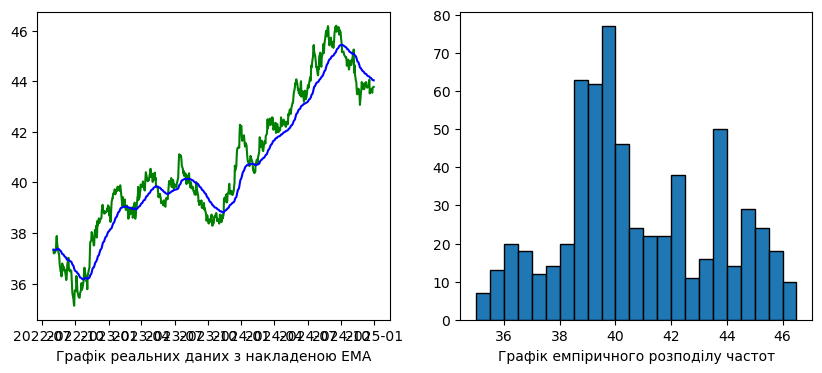

In [5]:
draw_plots(df_full, 'Date', 'Buy')

In [6]:
def prepare_regression_data(series, n_lags=5):
    data = pd.DataFrame(series.copy())
    data.columns = ['y']

    for i in range(1, n_lags + 1):
        data[f'lag_{i}'] = data['y'].shift(i)

    data.dropna(inplace=True)
    X = data.drop('y', axis=1)
    y = data['y']

    return X, y

# def create_mlp_model(n_layers=1, units=32, activation='relu', input_shape=None):
#     model = Sequential()
#     model.add(Input(shape=input_shape))
#
#     for _ in range(n_layers):
#         model.add(Dense(units, activation=activation))
#
#     model.add(Dense(1, activation='linear'))
#
#     model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#     return model

# def optimize_regression(X_train, y_train, input_shape):
#     keras_wrap = KerasRegressor(build_fn=create_mlp_model, input_shape=input_shape, verbose=0)
#
#     pipe = Pipeline([
#         ('scaler', MinMaxScaler()),
#         ('mlp', keras_wrap)
#     ])
#
#     param_grid = {
#         'mlp__n_layers': [1, 2, 3],
#         'mlp__units': [32, 64, 128],
#         'mlp__epochs': [50, 100],
#         'mlp__batch_size': [16, 32]
#     }
#     # tscv = TimeSeriesSplit(n_splits=5)
#     grid = GridSearchCV(
#         pipe,
#         param_grid,
#         # cv=tscv,
#         scoring='neg_root_mean_squared_error',
#         verbose=0,
#         n_jobs=-1
#     )
#     grid.fit(X_train, y_train)
#
#     print(f"Найкращі параметри Регресії: {grid.best_params_}")
#     return grid.best_estimator_, grid.score(X_train, y_train)

class MyDynamicRNN(nn.Module):
    def __init__(self, model_type: str, input_size: int, layer_sizes, dropouts):
        super().__init__()
        self.layers = nn.ModuleList()
        self.dropouts = nn.ModuleList(nn.Dropout(p) for p in dropouts)

        current_size = input_size
        for i, hidden_size in enumerate(layer_sizes):
            if model_type == 'LSTM':
                self.layers.append(nn.LSTM(current_size, hidden_size, batch_first=True))
            else:
                self.layers.append(nn.GRU(current_size, hidden_size, batch_first=True))

            current_size = hidden_size

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x, _ = layer(x)
            x = self.dropouts[i](x)

        out = x[:, -1, :]
        out = self.fc(out)

        return out

def objective(trial):
    rnn_type = trial.suggest_categorical("rnn_type", ["LSTM", "GRU"])
    n_layers = trial.suggest_int("n_layers", 1, 3)

    layer_sizes = []
    dropout_rates = []

    for i in range(n_layers):
        layer_sizes.append(trial.suggest_int(f"n_units_l{i}", 32, 128, step=16))
        dropout_rates.append(trial.suggest_float(f"dropout_l{i}", 0.2, 0.5, step=0.1))

    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Ініціалізація
    model = MyDynamicRNN(rnn_type, 1, layer_sizes, dropout_rates).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    epochs = 30
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            test_x_tensor = torch.FloatTensor(X_test).unsqueeze(-1).to(device)
            test_y_tensor = torch.FloatTensor(y_test).view(-1, 1).to(device)
            predictions = model(test_x_tensor)
            val_loss = criterion(predictions, test_y_tensor).item()

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss


def recursive_forecast(model, initial_lags, n_steps):
    current_features = initial_lags.to(device).view(1, -1).unsqueeze(-1)
    predictions = torch.tensor([], device=device)

    for _ in range(n_steps):
        pred = model(current_features)
        predictions = torch.concat([predictions, pred])
        current_features = torch.cat([pred.unsqueeze(-1), current_features[:, :-1]], dim=1)

    return predictions

In [41]:
lags_num = 10
X, y = prepare_regression_data(df_1['Buy'], n_lags=lags_num)
X_train, X_test, y_train, y_test = (data.to_numpy() for data in train_test_split(X, y, test_size=0.2, shuffle=False))

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(-1).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(-1).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

print(f"X_train shape: {X_train_tensor.shape}")
print(f"y_train shape: {y_train_tensor.shape}")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

X_train shape: torch.Size([409, 10, 1])
y_train shape: torch.Size([409, 1])


In [48]:
best_params = {'batch_size': 16}
train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=False)

storage_url = "sqlite:///lab7_optuna.db"
study = optuna.create_study(
    direction="minimize",
    storage=storage_url,
    study_name="time_series_rnn_v1",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(),
)

study.optimize(objective, n_trials=100)

print('\nНайкращі знайдені параметри')
print(study.best_params)

[I 2025-12-06 23:15:54,693] A new study created in RDB with name: time_series_rnn_v1
[I 2025-12-06 23:15:56,587] Trial 0 finished with value: 1735.1087646484375 and parameters: {'rnn_type': 'LSTM', 'n_layers': 2, 'n_units_l0': 80, 'dropout_l0': 0.4, 'n_units_l1': 80, 'dropout_l1': 0.30000000000000004, 'lr': 0.0006125050089192991, 'batch_size': 16}. Best is trial 0 with value: 1735.1087646484375.
[I 2025-12-06 23:15:57,618] Trial 1 finished with value: 1657.9520263671875 and parameters: {'rnn_type': 'GRU', 'n_layers': 3, 'n_units_l0': 128, 'dropout_l0': 0.5, 'n_units_l1': 64, 'dropout_l1': 0.30000000000000004, 'n_units_l2': 128, 'dropout_l2': 0.30000000000000004, 'lr': 0.000148580167723551, 'batch_size': 64}. Best is trial 1 with value: 1657.9520263671875.
[I 2025-12-06 23:15:58,712] Trial 2 finished with value: 1651.8656005859375 and parameters: {'rnn_type': 'GRU', 'n_layers': 2, 'n_units_l0': 32, 'dropout_l0': 0.4, 'n_units_l1': 128, 'dropout_l1': 0.30000000000000004, 'lr': 0.00088020


Найкращі знайдені параметри
{'rnn_type': 'LSTM', 'n_layers': 1, 'n_units_l0': 80, 'dropout_l0': 0.5, 'lr': 0.009884003718772334, 'batch_size': 16}


In [49]:
best_params = study.best_params
best_rnn_type = best_params["rnn_type"]
best_n_layers = best_params["n_layers"]
best_layer_sizes = [best_params[f"n_units_l{i}"] for i in range(best_n_layers)]
best_dropouts = [best_params[f"dropout_l{i}"] for i in range(best_n_layers)]

rnn_model = MyDynamicRNN(best_rnn_type, 1, best_layer_sizes, best_dropouts).to(device)
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=best_params["lr"])
criterion = nn.MSELoss()

loss_history = []
print(f"\nТренування моделі {best_rnn_type}:")
for epoch in range(100):
    rnn_model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = rnn_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    loss_history.append(epoch_loss / len(train_loader))

print('Тренування завершено')


Тренування моделі LSTM:
Тренування завершено


Модель: LSTM
RMSE: 2.9984
MAPE: 6.2858%
R2: -9.3892%


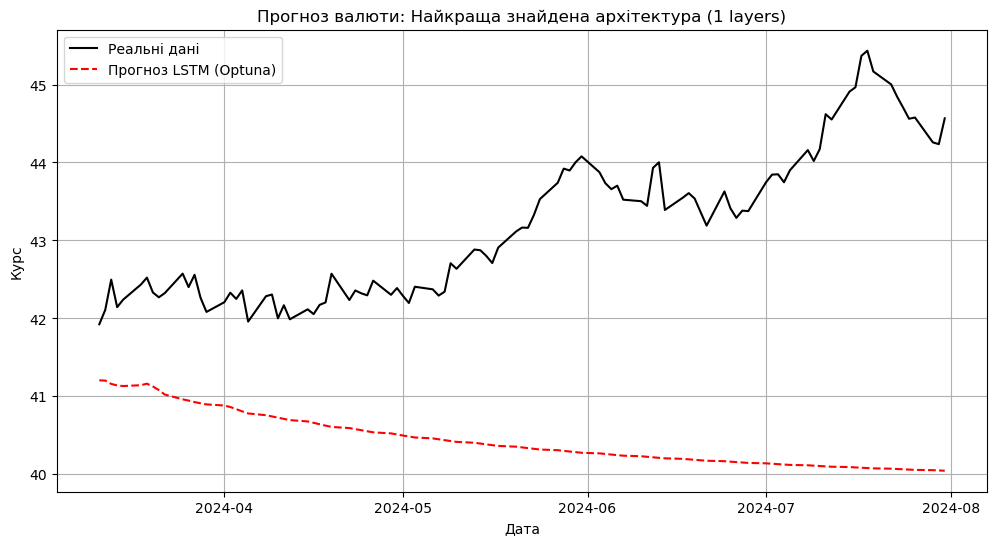

In [59]:
test_size = len(y_test)
rnn_model.eval()
with torch.no_grad():
    y_pred = recursive_forecast(rnn_model, X_train_tensor[-1].cpu(), test_size)
    y_pred_unscaled = scaler_y.inverse_transform(y_pred.cpu().numpy())

rmse, mape, r2 = evaluate_model(y_test, y_pred_unscaled, best_rnn_type)


# rnn_model.eval()
# with torch.no_grad():
#     pred_tensor = rnn_model(X_test_tensor)
#     pred_scaled = pred_tensor.cpu().numpy()
#
# pred_real = scaler_y.inverse_transform(pred_scaled)
# # y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
#
# rmse = np.sqrt(mean_squared_error(y_test, pred_real))
# mape = mean_absolute_percentage_error(y_test, pred_real) * 100
# r2 = r2_score(y_test, pred_real)
#
# print(f"\nРезультати моделі RNN:")
# print(f"RMSE: {rmse:.4f}")
# print(f"MAPE: {mape:.2f}%")
# print(f"R2: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(df_1['Date'].iloc[-test_size:], df_1['Buy'].iloc[-test_size:], label='Реальні дані', color='black')
plt.plot(df_1['Date'].iloc[-test_size:], y_pred_unscaled, label=f'Прогноз {best_rnn_type} (Optuna)', color='red', linestyle='--')
plt.title(f'Прогноз валюти: Найкраща знайдена архітектура ({best_n_layers} layers)')
plt.xlabel('Дата')
plt.ylabel('Курс')
plt.legend()
plt.grid(True)
plt.show()